In [2]:
# Install required libraries including SHAP for model explainability
!pip install openmeteo-requests requests-cache retry-requests shap xgboost scikit-learn tensorflow pandas numpy seaborn matplotlib scipy

import openmeteo_requests
import requests_cache
import pandas as pd
import numpy as np
from retry_requests import retry
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Setup Open-Meteo client with cache
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# 1. Fetch 6 Months of Data for Karachi
print("Fetching 180 days of historical data...")
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
end_date = datetime.now().date()
start_date = end_date - timedelta(days=180)

FEATURE_COLS = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust']
params = {
    "latitude": 24.8607,
    "longitude": 67.0011,
    "start_date": str(start_date),
    "end_date": str(end_date),
    "hourly": FEATURE_COLS + ["us_aqi"]
}

responses = openmeteo.weather_api(url, params=params)
hourly = responses[0].Hourly()

hourly_data = {"date": pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left"
)}

for i, col in enumerate(FEATURE_COLS + ["aqi"]):
    hourly_data[col] = hourly.Variables(i).ValuesAsNumpy()

df = pd.DataFrame(data=hourly_data)
df.set_index('date', inplace=True)

print(f"Data Fetched successfully! Shape: {df.shape}")
df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 685.7/685.7 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.8 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19
Fetching 180 days of historical data...
Data Fetched successfully! Shape: (4344, 8)


,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,aqi
date,,,,,,,,
2025-08-22 00:00:00+00:00,37.299999,32.400002,192.0,42.099998,23.500000,46.0,9.0,76.161346
2025-08-22 01:00:00+00:00,39.799999,33.299999,269.0,38.500000,23.500000,55.0,11.0,77.411354
2025-08-22 02:00:00+00:00,42.700001,34.799999,380.0,33.200001,23.400000,69.0,15.0,78.652489
2025-08-22 03:00:00+00:00,41.700001,32.000000,447.0,27.299999,23.000000,83.0,17.0,79.680862
2025-08-22 04:00:00+00:00,35.900002,26.799999,426.0,20.299999,22.200001,98.0,18.0,80.053192


--- 1. MISSING VALUE IMPUTATION ---
Missing values resolved. (Found and fixed 0)

--- 2. NOISE SMOOTHING ---

--- 3. OUTLIER TREATMENT (WINSORIZATION) ---
Data Cleaning Complete. Displaying Boxplots to verify outlier capping:


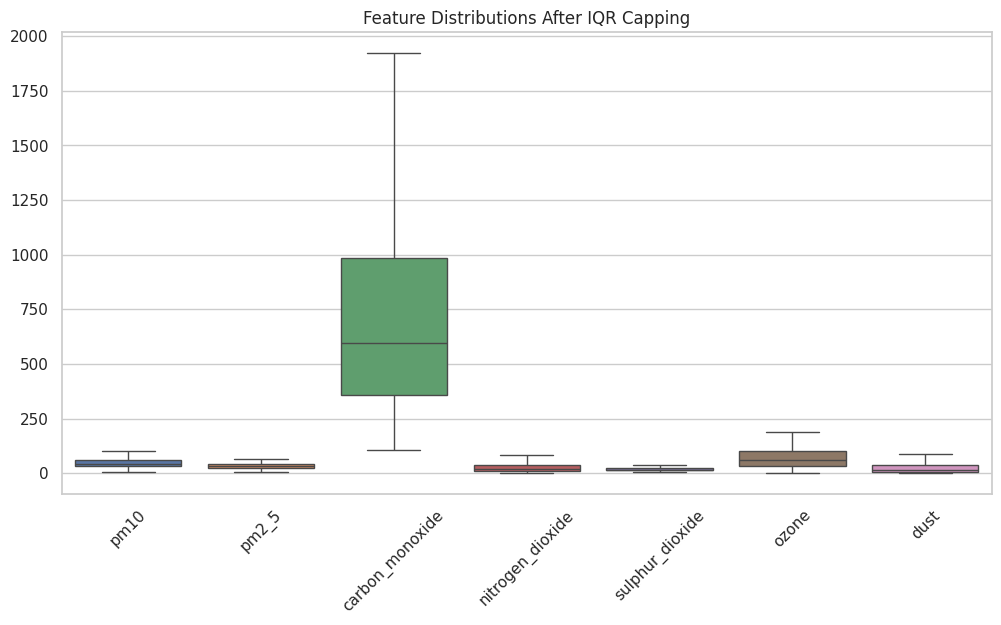

In [3]:
print("--- 1. MISSING VALUE IMPUTATION ---")
# Check missing values
missing_before = df.isnull().sum().sum()
# Impute using linear interpolation (best for continuous time-series)
df.interpolate(method='linear', inplace=True)
# Fill any remaining edge NAs with column means
df.fillna(df.mean(), inplace=True)
print(f"Missing values resolved. (Found and fixed {missing_before})")

print("\n--- 2. NOISE SMOOTHING ---")
# Apply a moving average to smooth short-term fluctuations (Noise reduction)
# We smooth the input features slightly, but keep the raw target 'aqi'
for col in FEATURE_COLS:
    df[f'{col}_smoothed'] = df[col].rolling(window=3, min_periods=1).mean()

print("\n--- 3. OUTLIER TREATMENT (WINSORIZATION) ---")
# Using the IQR method to cap extreme values instead of deleting them
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series.clip(lower=lower_bound, upper=upper_bound)

# Apply capping to smoothed features to avoid skewed models
for col in FEATURE_COLS:
    df[col] = cap_outliers_iqr(df[f'{col}_smoothed'])
    # Drop the temporary smoothed column to keep dataframe clean
    df.drop(columns=[f'{col}_smoothed'], inplace=True)

# Ensure no impossible negative values exist
df[df < 0] = 0

print("Data Cleaning Complete. Displaying Boxplots to verify outlier capping:")
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[FEATURE_COLS])
plt.xticks(rotation=45)
plt.title("Feature Distributions After IQR Capping")
plt.show()

--- MATHEMATICAL DATA TRANSFORMATION ---
Original Skewness:
pm10                0.747428
pm2_5               0.686312
carbon_monoxide     0.972105
nitrogen_dioxide    1.033793
sulphur_dioxide     0.906295
ozone               0.611089
dust                1.192188
dtype: float64

Applied Log Transformation to: ['nitrogen_dioxide', 'dust']


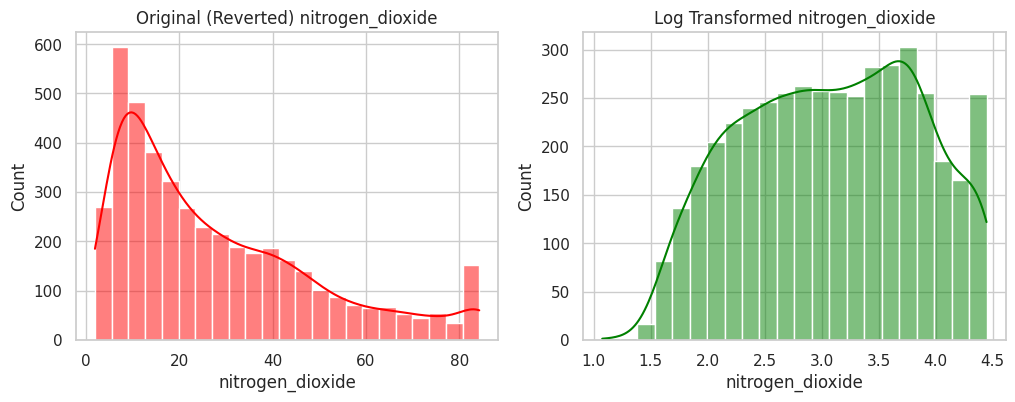

In [4]:
print("--- MATHEMATICAL DATA TRANSFORMATION ---")

# Calculate Skewness
skewness = df[FEATURE_COLS].apply(lambda x: stats.skew(x.dropna()))
print("Original Skewness:")
print(skewness)

# Apply Log Transformation to highly right-skewed variables (Skew > 1)
transformed_cols = []
for col in FEATURE_COLS:
    if skewness[col] > 1.0:
        # log(x+1) transformation handles 0 values safely
        df[col] = np.log1p(df[col])
        transformed_cols.append(col)

print(f"\nApplied Log Transformation to: {transformed_cols}")

# Visualize the transformation effect on the most skewed feature
if transformed_cols:
    sample_col = transformed_cols[0]
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(np.expm1(df[sample_col]), kde=True, color='red') # Reverted for visual comparison
    plt.title(f"Original (Reverted) {sample_col}")

    plt.subplot(1, 2, 2)
    sns.histplot(df[sample_col], kde=True, color='green')
    plt.title(f"Log Transformed {sample_col}")
    plt.show()


--- TREND IDENTIFICATION FOR NON-TECHNICAL AUDIENCE ---


/tmp/ipython-input-2928708226.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_df, x='Hour', y='aqi', ax=axes[1], errorbar=None, palette="viridis")
/tmp/ipython-input-2928708226.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eda_df, x='Day of Week', y='aqi', ax=axes[2], order=order, errorbar=None, palette="mako")


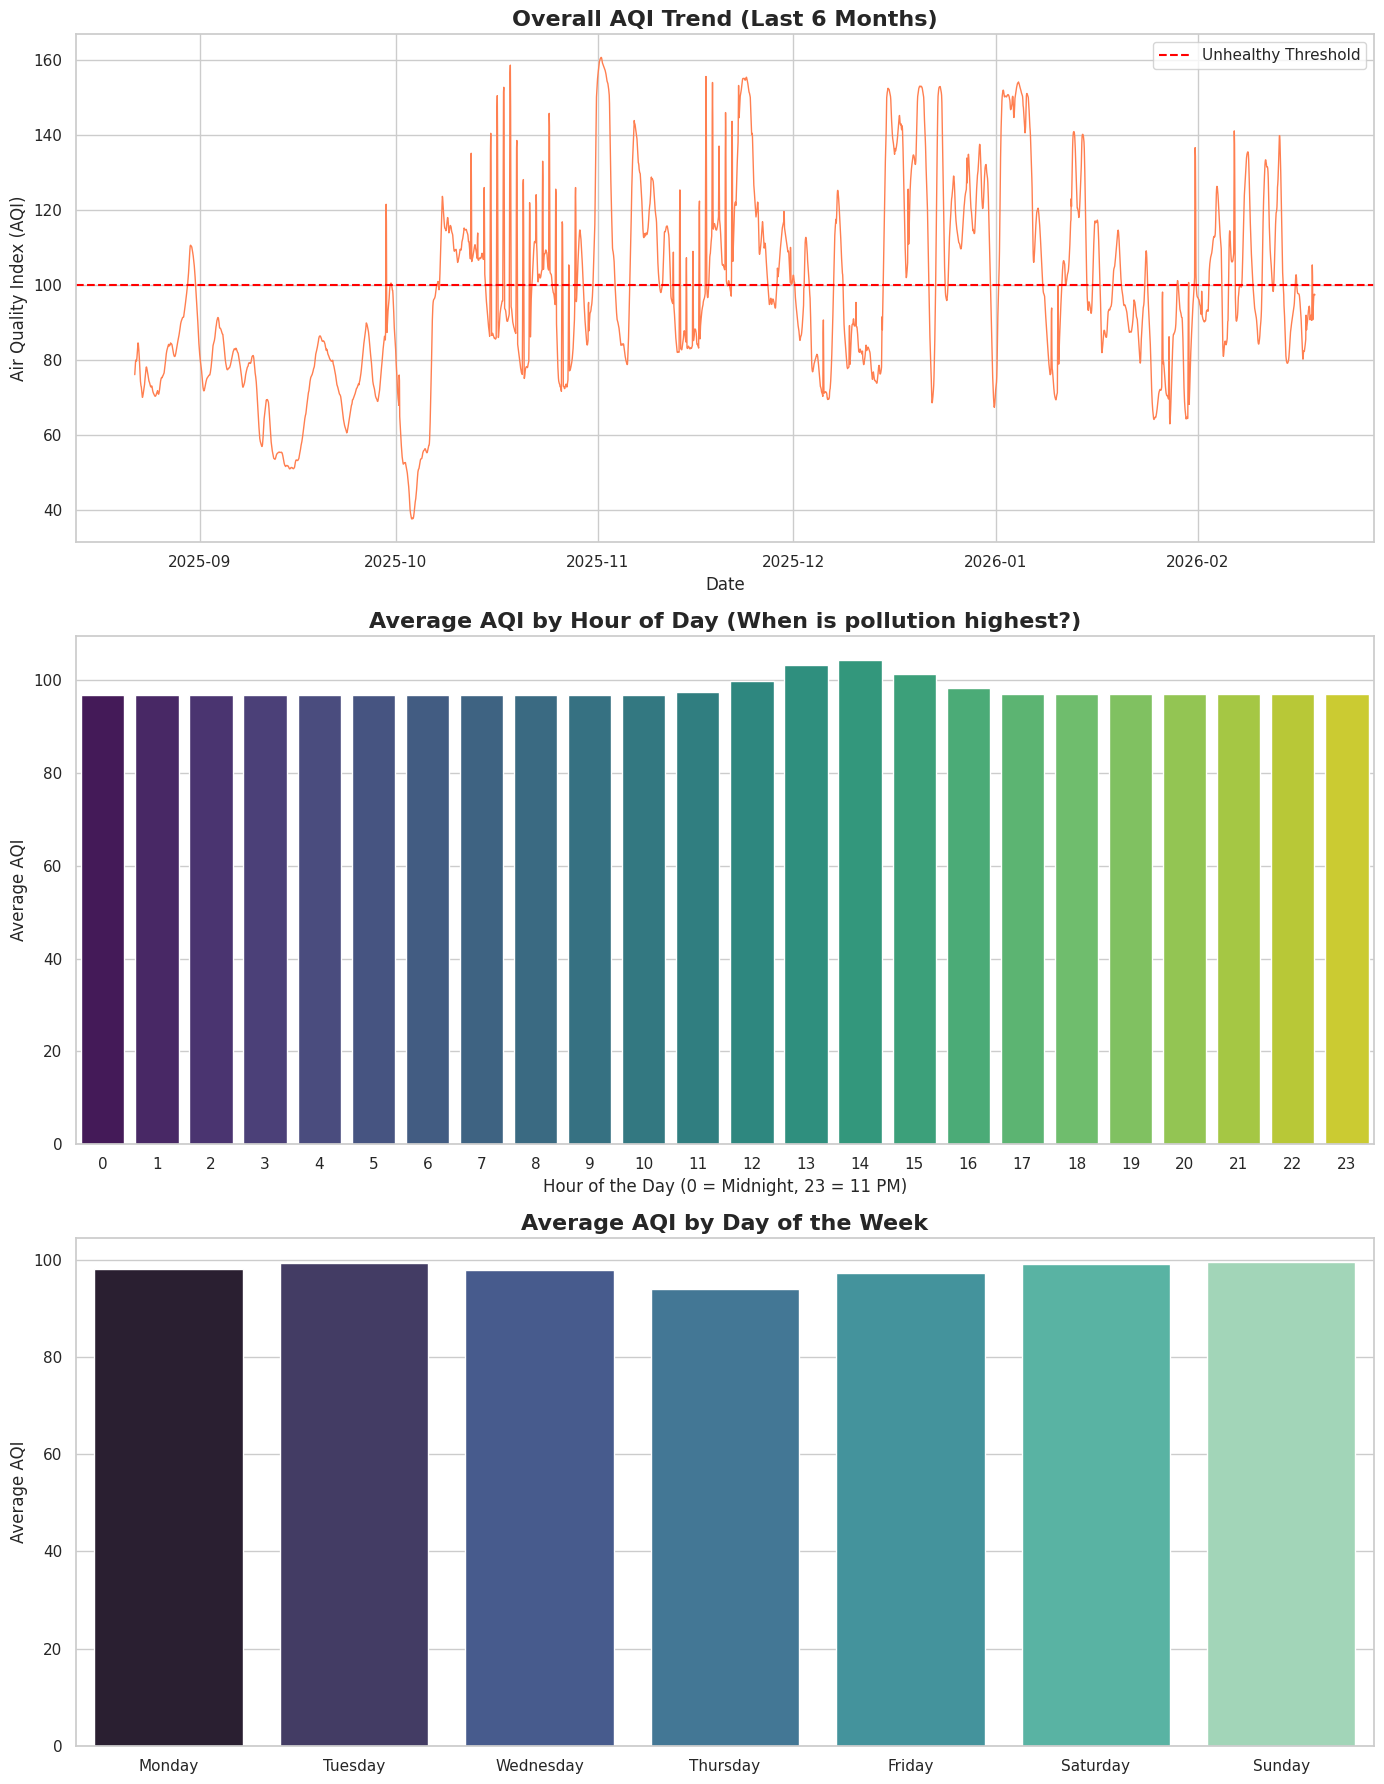

In [5]:
print("--- TREND IDENTIFICATION FOR NON-TECHNICAL AUDIENCE ---")
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Create a temporary dataframe with time features for visualization
eda_df = df.copy()
eda_df['Hour'] = eda_df.index.hour
eda_df['Day of Week'] = eda_df.index.day_name()
eda_df['Month'] = eda_df.index.month_name()

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# 1. Overall Trend over 6 months
sns.lineplot(data=eda_df, x=eda_df.index, y='aqi', ax=axes[0], color='coral', linewidth=1)
axes[0].set_title("Overall AQI Trend (Last 6 Months)", fontsize=16, fontweight='bold')
axes[0].set_ylabel("Air Quality Index (AQI)")
axes[0].set_xlabel("Date")
axes[0].axhline(100, color='red', linestyle='--', label="Unhealthy Threshold")
axes[0].legend()

# 2. Daily Rhythm (Traffic/Industrial impact)
sns.barplot(data=eda_df, x='Hour', y='aqi', ax=axes[1], errorbar=None, palette="viridis")
axes[1].set_title("Average AQI by Hour of Day (When is pollution highest?)", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Average AQI")
axes[1].set_xlabel("Hour of the Day (0 = Midnight, 23 = 11 PM)")

# 3. Weekly Rhythm (Weekend vs Weekday)
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.barplot(data=eda_df, x='Day of Week', y='aqi', ax=axes[2], order=order, errorbar=None, palette="mako")
axes[2].set_title("Average AQI by Day of the Week", fontsize=16, fontweight='bold')
axes[2].set_ylabel("Average AQI")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

--- FEATURE ENGINEERING ---


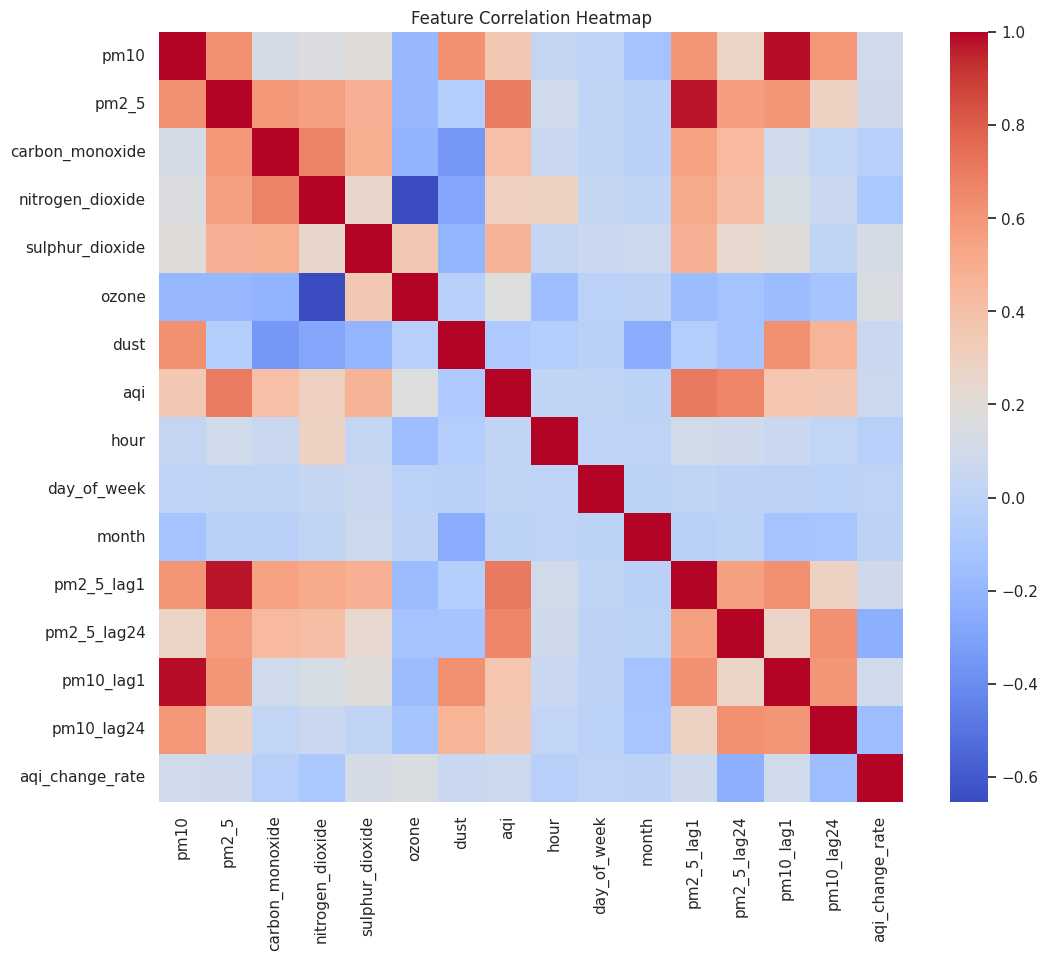

Final Input Features (15): ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust', 'hour', 'day_of_week', 'month', 'pm2_5_lag1', 'pm2_5_lag24', 'pm10_lag1', 'pm10_lag24', 'aqi_change_rate']


In [6]:
print("--- FEATURE ENGINEERING ---")

# 1. Time-based features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

# 2. Derived features: Lags & Rolling averages
# How was the pollution 1 hour ago and 24 hours ago?
for col in ['pm2_5', 'pm10']:
    df[f'{col}_lag1'] = df[col].shift(1)
    df[f'{col}_lag24'] = df[col].shift(24)

# 3. AQI Change Rate (Derivative) - As explicitly requested by 10Pearls docs
df['aqi_change_rate'] = df['aqi'].diff()

# Drop rows with NaNs introduced by shifting
df.dropna(inplace=True)

# 4. Redundancy Analysis (Filter Method)
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Extract final features and target
TARGET = 'aqi'
FEATURES = [c for c in df.columns if c != TARGET]
print(f"Final Input Features ({len(FEATURES)}): {FEATURES}")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("--- STANDARDIZATION & SCALING ---")
# Chronological Split (No random shuffling for time series)
split_idx = int(len(df) * 0.8)
train_df, test_df = df.iloc[:split_idx], df.iloc[split_idx:]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

# Min-Max Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"[{name}] RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.4f}")
    return rmse

# 1. Random Forest
print("\nTraining Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_rmse = evaluate("Random Forest", y_test, rf.predict(X_test_scaled))

# 2. XGBoost
print("\nTraining XGBoost...")
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
xgb.fit(X_train_scaled, y_train)
xgb_rmse = evaluate("XGBoost", y_test, xgb.predict(X_test_scaled))

# 3. LSTM (Deep Learning) - Fixed Architecture
print("\nTraining Deep Learning LSTM...")
# LSTM requires 3D shape [samples, time steps, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

lstm_model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(1, X_train_scaled.shape[1])),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=32,
               validation_data=(X_test_lstm, y_test), callbacks=[early_stop], verbose=0)

lstm_rmse = evaluate("LSTM", y_test, lstm_model.predict(X_test_lstm, verbose=0).flatten())

--- STANDARDIZATION & SCALING ---

Training Random Forest...
[Random Forest] RMSE: 16.21 | MAE: 12.34 | R2: 0.1809

Training XGBoost...
[XGBoost] RMSE: 14.96 | MAE: 11.51 | R2: 0.3029

Training Deep Learning LSTM...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[LSTM] RMSE: 14.15 | MAE: 10.72 | R2: 0.3759


--- MODEL EXPLAINABILITY (SHAP) ---


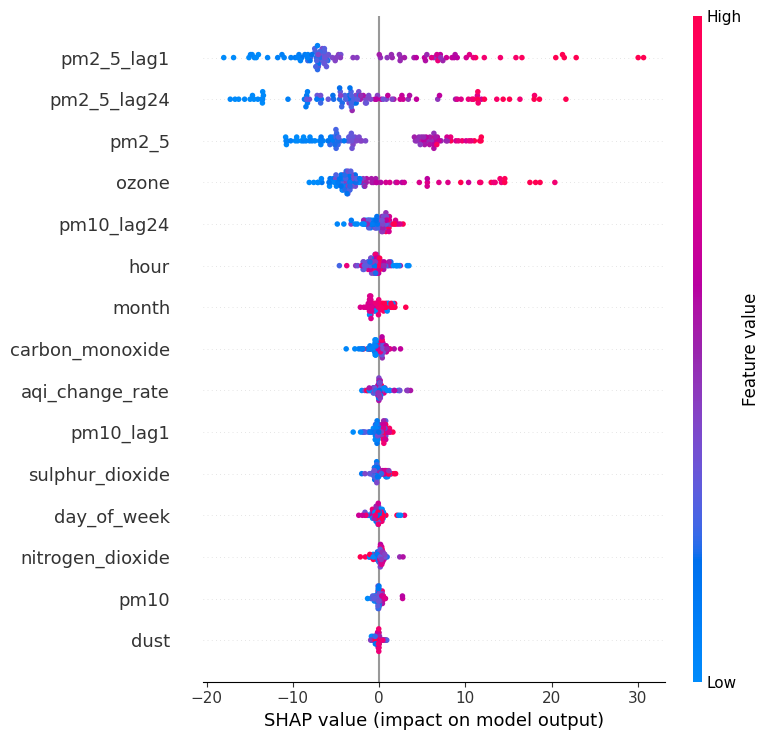

In [ ]:
import shap

print("--- MODEL EXPLAINABILITY (SHAP) ---")
# We will explain the Random Forest model (usually the most stable performer)
# Using a sample of data to compute SHAP values quickly
X_train_sample = shap.sample(X_train_scaled, 100)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train_sample)

# Visualize feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_sample, feature_names=FEATURES)